In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(".\Datasets\churn-modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [6]:
for i in ['Surname', 'Geography', 'Gender']: print(i, ':\n', df[i].unique())

Surname :
 ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
Geography :
 ['France' 'Spain' 'Germany']
Gender :
 ['Female' 'Male']


In [7]:
pd.Series(df.Surname.unique()).to_string().split('\n')

['0                      Hargrave',
 '1                          Hill',
 '2                          Onio',
 '3                          Boni',
 '4                      Mitchell',
 '5                           Chu',
 '6                      Bartlett',
 '7                        Obinna',
 '8                            He',
 '9                            H?',
 '10                       Bearce',
 '11                      Andrews',
 '12                          Kay',
 '13                         Chin',
 '14                        Scott',
 '15                      Goforth',
 '16                        Romeo',
 '17                    Henderson',
 '18                      Muldrow',
 '19                          Hao',
 '20                     McDonald',
 '21                     Dellucci',
 '22                    Gerasimov',
 '23                       Mosman',
 '24                          Yen',
 '25                      Maclean',
 '26                        Young',
 '27                      Ne

In [8]:
df.shape

(10000, 14)

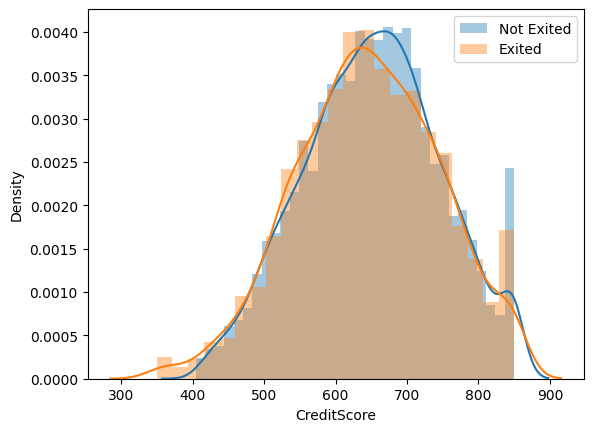

In [9]:
sns.distplot(df.CreditScore[df.Exited == 0], label = 'Not Exited')
sns.distplot(df.CreditScore[df.Exited == 1], label = 'Exited')
plt.legend()
plt.show()

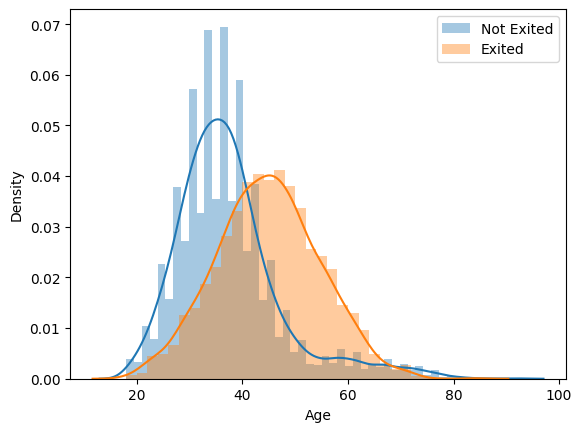

In [10]:
sns.distplot(df.Age[df.Exited == 0], label = 'Not Exited')
sns.distplot(df.Age[df.Exited == 1], label = 'Exited')
plt.legend()
plt.show()

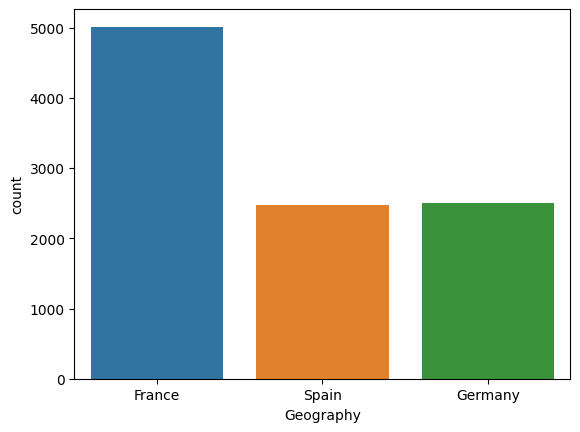

In [11]:
sns.countplot(x = df.Geography)
plt.show()

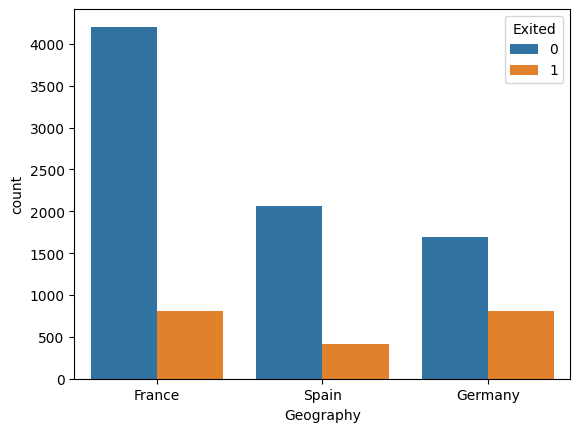

In [12]:
sns.countplot(x = df.Geography, hue = df.Exited)
plt.show()

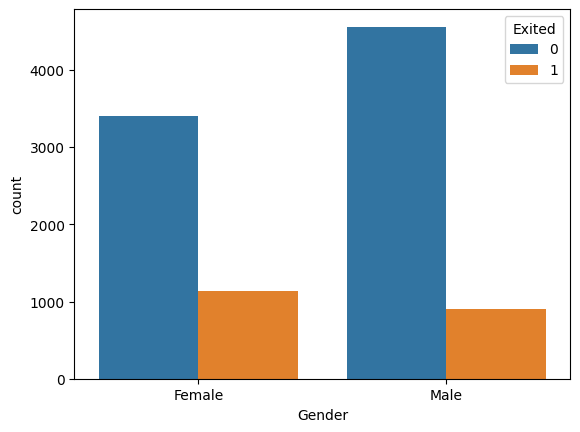

In [13]:
sns.countplot(x = df.Gender, hue = df.Exited)
plt.show()

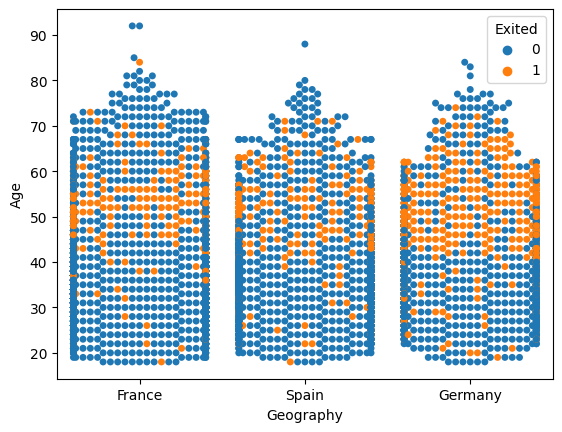

In [14]:
sns.swarmplot(x = df.Geography, y = df.Age, hue = df.Exited)
plt.show()

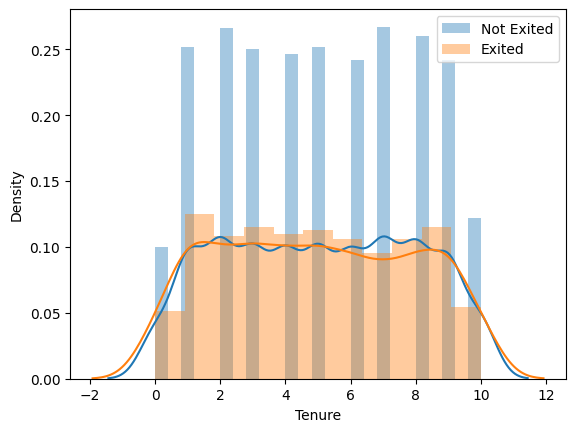

In [15]:
sns.distplot(df.Tenure[df.Exited == 0], label = 'Not Exited')
sns.distplot(df.Tenure[df.Exited == 1], label = 'Exited')
plt.legend()
plt.show()

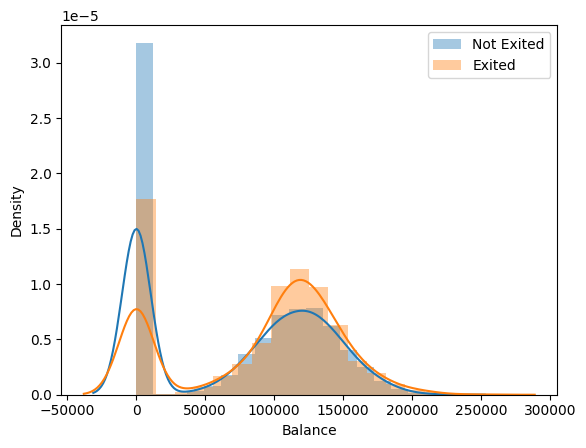

In [16]:
sns.distplot(df.Balance[df.Exited == 0], label = 'Not Exited')
sns.distplot(df.Balance[df.Exited == 1], label = 'Exited')
plt.legend()
plt.show()

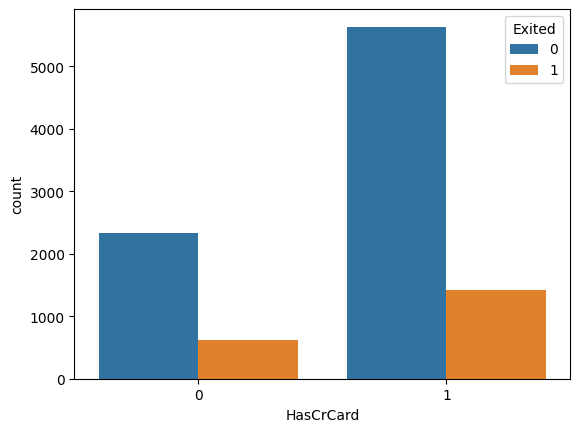

In [17]:
sns.countplot(x = df.HasCrCard, hue = df.Exited)
plt.show()

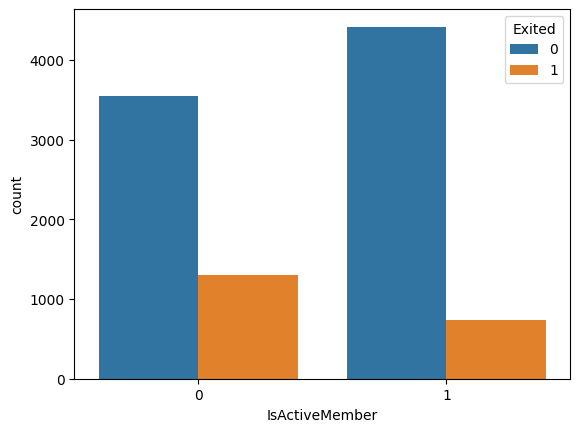

In [18]:
sns.countplot(x = df.IsActiveMember, hue = df.Exited)
plt.show()

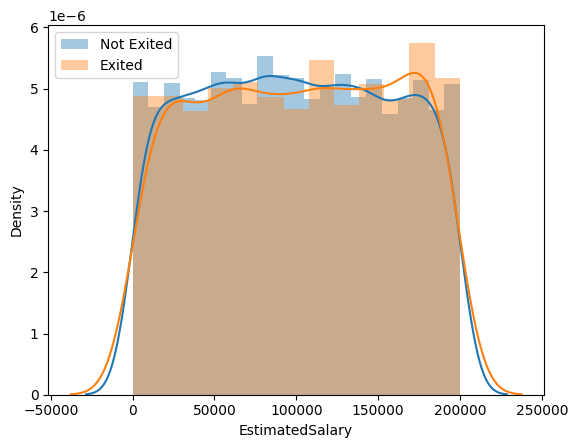

In [19]:
sns.distplot(df.EstimatedSalary[df.Exited == 0], label = 'Not Exited')
sns.distplot(df.EstimatedSalary[df.Exited == 1], label = 'Exited')
plt.legend()
plt.show()

In [20]:
df1 = df.drop(['Surname', 'RowNumber', 'CustomerId'], axis = 1)
df1

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [21]:
le = LabelEncoder()
df1.Geography = le.fit_transform(df1.Geography)
le

LabelEncoder()

In [22]:
le1 = LabelEncoder()
df1.Gender = le1.fit_transform(df1.Gender)
le1

LabelEncoder()

In [23]:
df1

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [24]:
df_corr = df1.corr()
df_corr

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.007888,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Geography,0.007888,1.000000,0.004719,0.022812,0.003739,0.069408,0.003972,-0.008523,0.006724,-0.001369,0.035943
Gender,-0.002857,0.004719,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512
Age,-0.003965,0.022812,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,0.003739,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.069408,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,0.003972,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.008523,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.006724,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.001369,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


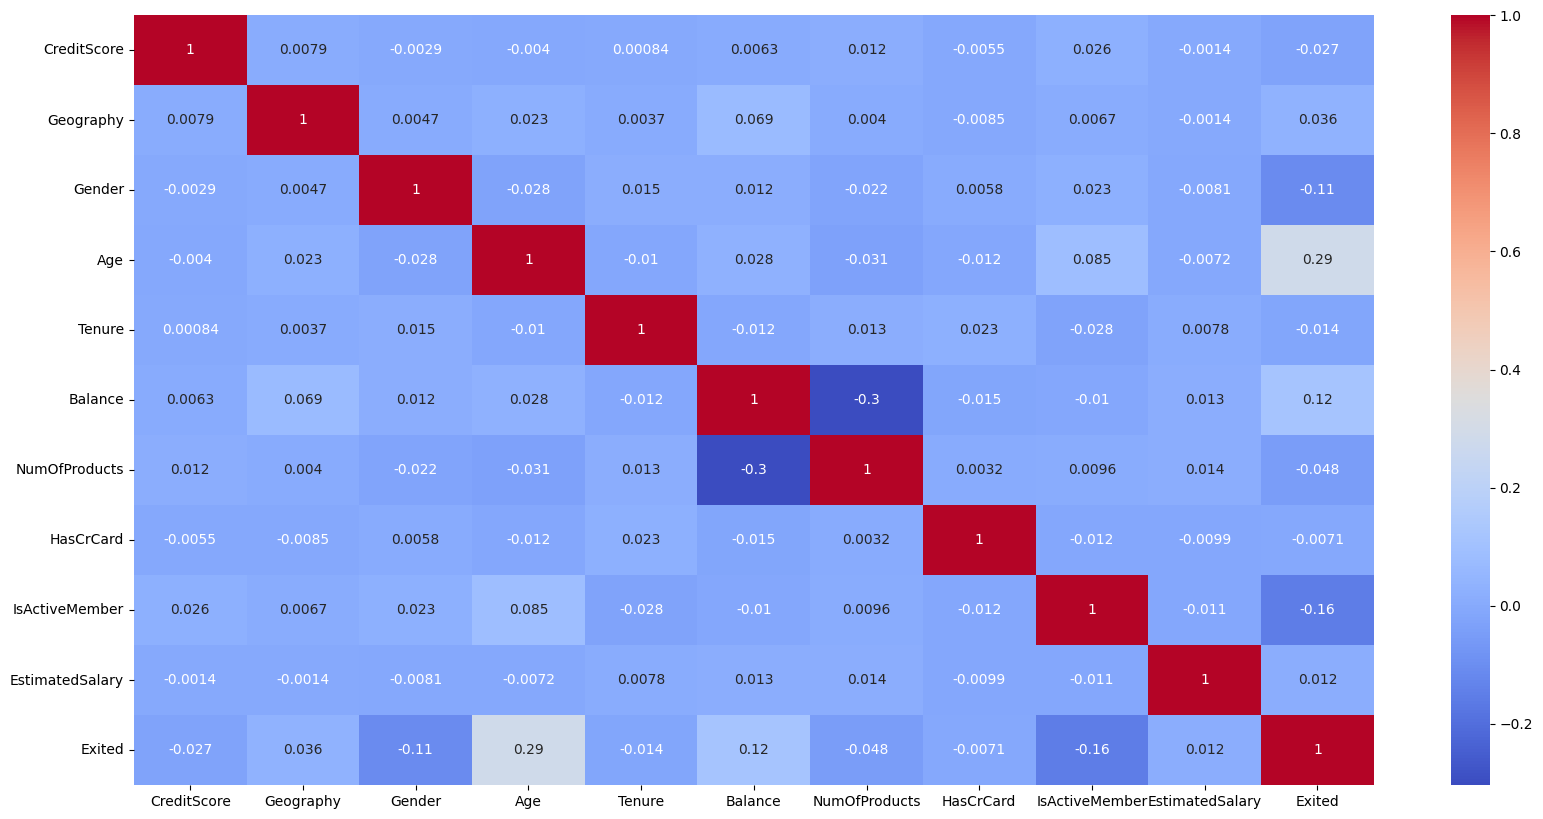

In [29]:
plt.figure(figsize = (20,10))
sns.heatmap(df_corr, annot = True, cmap = 'coolwarm')
plt.show()